# Fused CV benchmarks

Compare fused CV with sequential external-memory and in-memory CV on one GPU.
Both baselines use **fold-local cuts**; fused CV uses full-data cuts, so RMSE can differ.
All methods use identical folds and return host OOF predictions after a fixed number
of rounds. Data generation is excluded; construction, training, and prediction are timed.

Edit the settings below and run all cells with this branch's CUDA-enabled XGBoost.
Increase the dataset sizes for external-memory workloads; the in-memory baseline needs
one fold's training/validation matrices and training state to fit on the GPU.

In [5]:
import gc
from contextlib import contextmanager
from time import perf_counter

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import _cross_validation as xcv

GPU_ID = 0
ROW_COUNTS = [2**16, 2**18, 2**20]
N_FEATURES = 64
K_FOLDS = 5
N_ROUNDS = 32
BATCH_ROWS = 2**16
SEED = 2026
CACHE_HOST_RATIO = 1.0  # Keep both external-memory caches on the host.
TREE_PARAMS = {
    "max_depth": 6,
    "max_bin": 256,
    "learning_rate": 0.1,
    # Total budget for fused CV; per active booster for sequential CV.
    "max_cached_hist_node": 256,
}

cp.cuda.Device(GPU_ID).use()
gpu_pool = cp.cuda.MemoryAsyncPool(pool_handles="default")
cp.cuda.set_allocator(gpu_pool.malloc)
xgb.set_config(use_cuda_async_pool=True, verbosity=0)
BASELINE_PARAMS = {
    **TREE_PARAMS,
    "device": f"cuda:{GPU_ID}",
    "tree_method": "hist",
    "objective": "reg:squarederror",
    "base_score": 0.5,
    "boost_from_average": 0,
    "multi_strategy": "multi_output_tree",
}
METHODS = ["Fused CV", "Sequential external-memory CV", "Sequential in-memory CV"]

The iterator stages one batch at a time and preserves row order. Training matrices
for the baselines compute their own cuts; validation matrices use `ref=train`.
Replace `make_data` with your own host-array loader if needed.

In [6]:
def make_data(n_rows, n_features, seed):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n_rows, n_features), dtype=np.float32)
    y = (
        2.0 * X[:, 0]
        + 0.5 * X[:, 1] ** 2
        + np.sin(X[:, 2])
        + (X[:, 0] > 0) * X[:, 3]
        + 0.1 * rng.standard_normal(n_rows, dtype=np.float32)
    ).astype(np.float32)
    return X, y


def make_fold_ids(n_rows):
    ids = np.arange(n_rows, dtype=np.int32) % K_FOLDS
    np.random.default_rng(SEED + 1).shuffle(ids)
    return ids


class HostBatchIter(xgb.DataIter):
    def __init__(self, X, y, ids, *, fold=None, validation=False):
        super().__init__(cache_prefix=None, on_host=True, release_data=True)
        self.X, self.y, self.ids = X, y, ids
        self.fold, self.validation = fold, validation
        self.position = 0

    def reset(self):
        self.position = 0

    def next(self, input_data):
        while self.position < len(self.y):
            begin = self.position
            end = min(begin + BATCH_ROWS, len(self.y))
            self.position = end
            X, y = self.X[begin:end], self.y[begin:end]
            if self.fold is not None:
                keep = self.ids[begin:end] == self.fold
                if not self.validation:
                    keep = ~keep
                if not keep.any():
                    continue
                X, y = X[keep], y[keep]
            input_data(data=cp.asarray(X), label=cp.asarray(y))
            return True
        return False


def make_matrix(X, y, ids, *, external, fold=None, validation=False, ref=None):
    iterator = HostBatchIter(X, y, ids, fold=fold, validation=validation)
    kwargs = {"max_bin": TREE_PARAMS["max_bin"], "ref": ref}
    if external:
        return xgb.ExtMemQuantileDMatrix(
            iterator, cache_host_ratio=CACHE_HOST_RATIO, **kwargs
        )
    return xgb.QuantileDMatrix(iterator, **kwargs)

In [7]:
def stamp():
    cp.cuda.runtime.deviceSynchronize()
    return perf_counter()


@contextmanager
def timed(times, phase):
    start = stamp()
    yield
    times[phase] += stamp() - start


def release_unused():
    gc.collect()
    cp.cuda.runtime.deviceSynchronize()
    gpu_pool.free_all_blocks()

In [8]:
def run_fused(X, y, ids, rounds):
    times = dict.fromkeys(["build_s", "train_s", "predict_s"], 0.0)
    with timed(times, "build_s"):
        data = make_matrix(X, y, ids, external=True)
        assignment = xcv.FoldAssignment(ids, k_folds=K_FOLDS)
        models = xcv.FoldModels(data, K_FOLDS)
        predictions = xcv.FoldPredictions()
        models.init_prediction(data, predictions, assignment=assignment)
        gradients = xcv.FoldGpairs()
        updater = xcv.FoldTreeMethod(models, data, params=TREE_PARAMS)
    with timed(times, "train_s"):
        for iteration in range(rounds):
            models.get_gradient(data, iteration, predictions, out=gradients)
            updater.update(models, data, gradients, predictions)
    with timed(times, "predict_s"):
        oof = cp.asnumpy(predictions.get_valid(copy=False)).reshape(-1)
    return times, oof


def run_sequential(X, y, ids, rounds, *, external):
    times = dict.fromkeys(["build_s", "train_s", "predict_s"], 0.0)
    with timed(times, "build_s"):
        oof = np.full(len(y), np.nan, dtype=np.float32)
    for fold in range(K_FOLDS):
        with timed(times, "build_s"):
            train = make_matrix(X, y, ids, external=external, fold=fold)
            valid = make_matrix(
                X, y, ids, external=external, fold=fold, validation=True, ref=train
            )
            model = xgb.Booster(BASELINE_PARAMS, cache=[train, valid])
        with timed(times, "train_s"):
            for iteration in range(rounds):
                model.update(train, iteration)
        with timed(times, "predict_s"):
            oof[ids == fold] = model.predict(valid, output_margin=True).reshape(-1)
        # Release this fold before constructing the next one.
        del model, valid, train
    return times, oof


def run_once(method, X, y, ids, rounds):
    start = stamp()
    if method == "Fused CV":
        times, oof = run_fused(X, y, ids, rounds)
    else:
        times, oof = run_sequential(
            X, y, ids, rounds, external=method == "Sequential external-memory CV"
        )
    times["total_s"] = stamp() - start
    times["fit_oof_s"] = times["train_s"] + times["predict_s"]
    assert oof.shape == y.shape and np.isfinite(oof).all()
    # Scoring is common to all methods and is outside the timers.
    squared_error = (oof.astype(np.float64) - y) ** 2
    fold_rmse = [float(np.sqrt(squared_error[ids == k].mean())) for k in range(K_FOLDS)]
    times["mean_fold_rmse"] = float(np.mean(fold_rmse))
    return times

Each method gets a small warm-up, then one measured CV run per dataset size.
Each run uses fresh matrices and models.
Method order is randomized. CUDA is synchronized at timing boundaries.
Total time includes construction and cleanup; `fit_oof_s` measures training plus
prediction. Fused CV computes OOF predictions during training. RMSE is scored afterward.

In [9]:
X, y = make_data(max(2048, K_FOLDS * 8), N_FEATURES, SEED)
ids = make_fold_ids(len(y))
for method in METHODS:
    release_unused()
    run_once(method, X, y, ids, rounds=2)
del X, y, ids

records = []
order_rng = np.random.default_rng(SEED + 2)
for n_rows in ROW_COUNTS:
    X, y = make_data(n_rows, N_FEATURES, SEED)
    ids = make_fold_ids(n_rows)
    for method in order_rng.permutation(METHODS):
        release_unused()
        stats = run_once(method, X, y, ids, N_ROUNDS)
        records.append(dict(method=method, n_rows=n_rows, **stats))
        print(f"{n_rows:,} rows | {method} | {stats['total_s']:.3f}s")
    del X, y, ids
release_unused()

results = pd.DataFrame(records)
summary = results.set_index(["n_rows", "method"]).sort_index()
summary.round(4)

65,536 rows | Fused CV | 0.443s
65,536 rows | Sequential in-memory CV | 0.294s
65,536 rows | Sequential external-memory CV | 0.321s
262,144 rows | Fused CV | 0.483s
262,144 rows | Sequential external-memory CV | 0.544s
262,144 rows | Sequential in-memory CV | 0.506s
1,048,576 rows | Sequential in-memory CV | 1.392s
1,048,576 rows | Fused CV | 0.918s
1,048,576 rows | Sequential external-memory CV | 1.429s


build_s  train_s  predict_s  total_s  \
n_rows  method                                                                
65536   Fused CV                        0.0160   0.4215     0.0003   0.4431   
        Sequential external-memory CV   0.0704   0.2411     0.0032   0.3211   
        Sequential in-memory CV         0.0665   0.2203     0.0031   0.2938   
262144  Fused CV                        0.0314   0.4468     0.0002   0.4825   
        Sequential external-memory CV   0.2311   0.2997     0.0067   0.5438   
        Sequential in-memory CV         0.2218   0.2752     0.0054   0.5056   
1048576 Fused CV                        0.1086   0.8051     0.0005   0.9183   
        Sequential external-memory CV   0.8233   0.5827     0.0164   1.4290   
        Sequential in-memory CV         0.8163   0.5561     0.0161   1.3925   

                                       fit_oof_s  mean_fold_rmse  
n_rows  method                                                    
65536   Fused CV                          0.4218          0.3139  
        Sequential external-memory CV     0.2443          0.3143  
        Sequential in-memory CV           0.2235          0.3143  
262144  Fused CV                          0.4470          0.3022  
        Sequential external-memory CV     0.3065          0.3051  
        Sequential in-memory CV           0.2806          0.3051  
1048576 Fused CV                          0.8056          0.2980  
        Sequential external-memory CV     0.5990          0.2991  
        Sequential in-memory CV           0.5722          0.2991

Plots show one CV run per method and dataset size. Speedup is baseline total time
divided by fused total time at the same dataset size; values above one favor fusion.

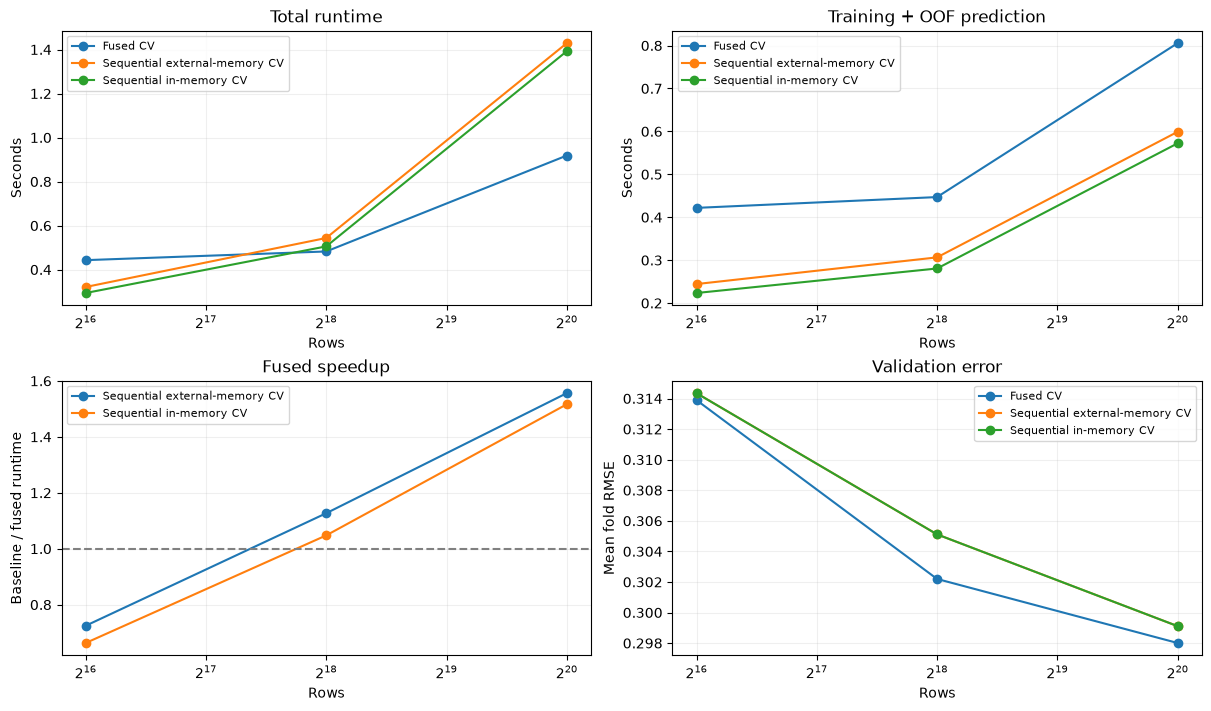

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout="constrained")
for ax, column, title, ylabel in [
    (axes[0, 0], "total_s", "Total runtime", "Seconds"),
    (axes[0, 1], "fit_oof_s", "Training + OOF prediction", "Seconds"),
    (axes[1, 1], "mean_fold_rmse", "Validation error", "Mean fold RMSE"),
]:
    summary[column].unstack("method").reindex(columns=METHODS).plot(ax=ax, marker="o")
    ax.set(title=title, ylabel=ylabel)

paired = results.pivot(index="n_rows", columns="method", values="total_s")
speedup = paired[METHODS[1:]].div(paired["Fused CV"], axis=0)
speedup.plot(ax=axes[1, 0], marker="o")
axes[1, 0].axhline(1, color="gray", linestyle="--")
axes[1, 0].set(title="Fused speedup", ylabel="Baseline / fused runtime")
for ax in axes.flat:
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Rows")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
plt.show()